1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


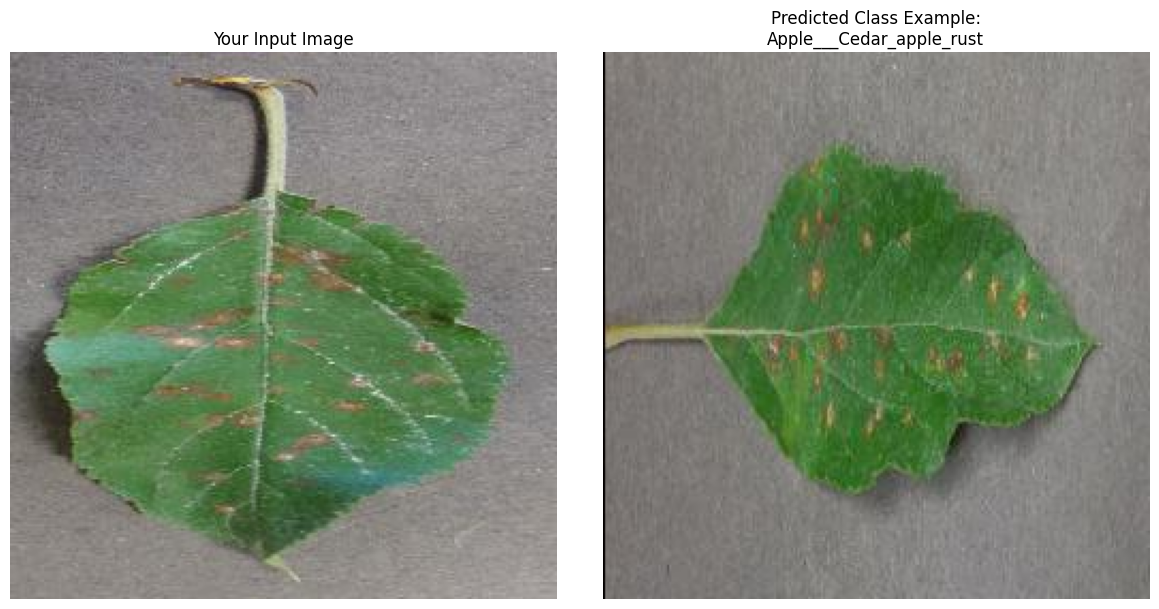


Predicted Class: Apple___Cedar_apple_rust


In [19]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from PIL import Image
import json
import matplotlib.pyplot as plt
import os
import random

# -----------------------------
# Load model and class indices
# -----------------------------
model = load_model("best_model.h5")

with open("class_indices.json", "r") as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}

# -----------------------------
# Preprocess function
# -----------------------------
def preprocess_image(img_path, img_size=(224, 224)):
    img = Image.open(img_path).convert("RGB")
    img_resized = img.resize(img_size)
    img_array = np.array(img_resized).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img  # return original too for display

# -----------------------------
# Predict function
# -----------------------------
def predict_class(img_path):
    img_array, original_img = preprocess_image(img_path)
    preds = model.predict(img_array)
    class_index = np.argmax(preds)
    class_name = index_to_class[class_index]
    return class_name, original_img

# -----------------------------
# Show side-by-side comparison
# -----------------------------
def show_side_by_side(input_img_path, dataset_base_folder):
    predicted_class, original_img = predict_class(input_img_path)

    # Get folder of predicted class from dataset
    predicted_folder = os.path.join(dataset_base_folder, predicted_class)

    # Pick a random image from predicted class folder as reference
    reference_image_name = random.choice(os.listdir(predicted_folder))
    reference_image_path = os.path.join(predicted_folder, reference_image_name)
    reference_img = Image.open(reference_image_path)

    # Plot Side-by-Side
    plt.figure(figsize=(12, 6))

    # Left: Your Test Image
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Your Input Image")
    plt.axis("off")

    # Right: Reference Healthy/Disease Example
    plt.subplot(1, 2, 2)
    plt.imshow(reference_img)
    plt.title(f"Predicted Class Example:\n{predicted_class}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"\nPredicted Class: {predicted_class}")

# -----------------------------
# RUN HERE
# -----------------------------
test_image = r"C:\Users\2k22c\FinalYear\Agro-Tech\test\test\AppleCedarRust2.JPG"

# Path to your TRAIN dataset folder
dataset_path = r"C:\Users\2k22c\FinalYear\Agro-Tech\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train"

show_side_by_side(test_image, dataset_path)
